# Sales Prediction using Python

**1. Business Understanding**

## Problem Statement

The company spends money on TV, Radio, and Newspaper advertisements.

The objective is to predict product sales based on advertising expenditure.

## Business Goal

- Understand which advertising platform contributes most to sales.
- Build a machine learning model to predict future sales.
- Help companies optimize advertising budgets.

**2. Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

**3. Load Dataset**

In [3]:
df = pd.read_csv('Advertising.csv')

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


**4. Dataset Overview**

In [4]:
df.shape

(200, 5)

In [5]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [7]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


**5. Data Cleaning**

In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop('Unnamed: 0', axis = 1, inplace = True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


**6. Exploratory Data Analysis (EDA)**

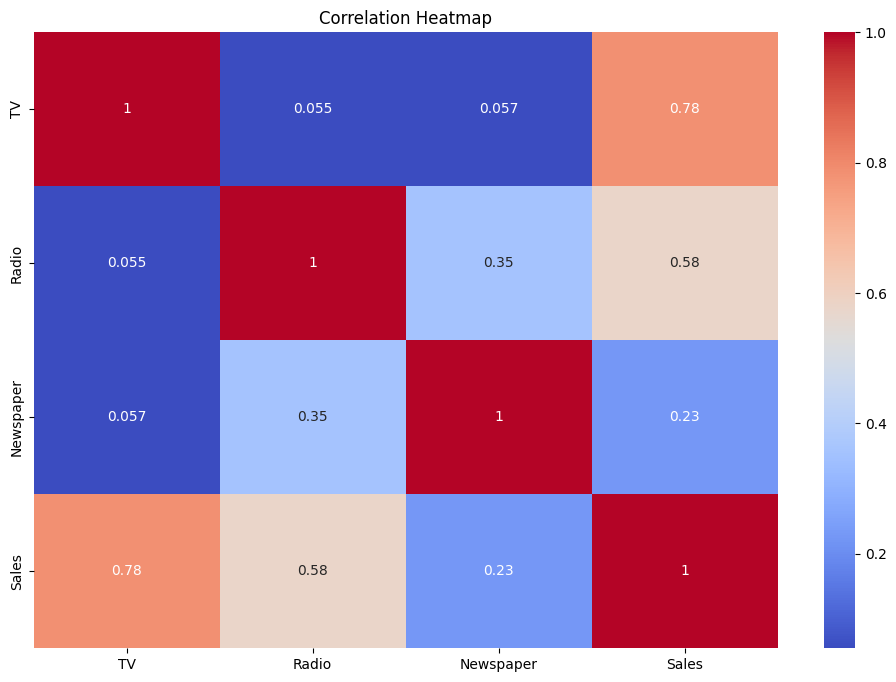

In [11]:
#correlation heatmap to see and understand the relation between numerical variables

plt.figure(figsize = (12, 8))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

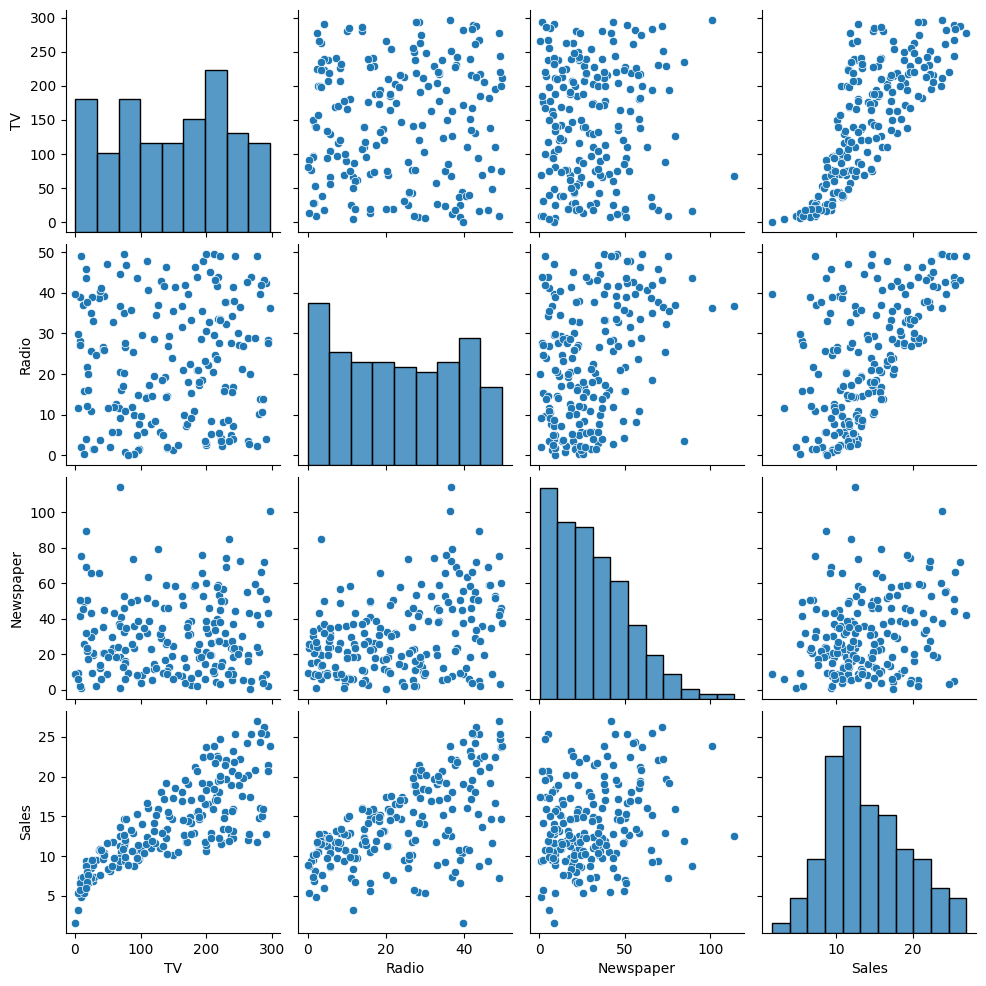

In [12]:
#pairplot to check wise relations

sns.pairplot(df)
plt.show()

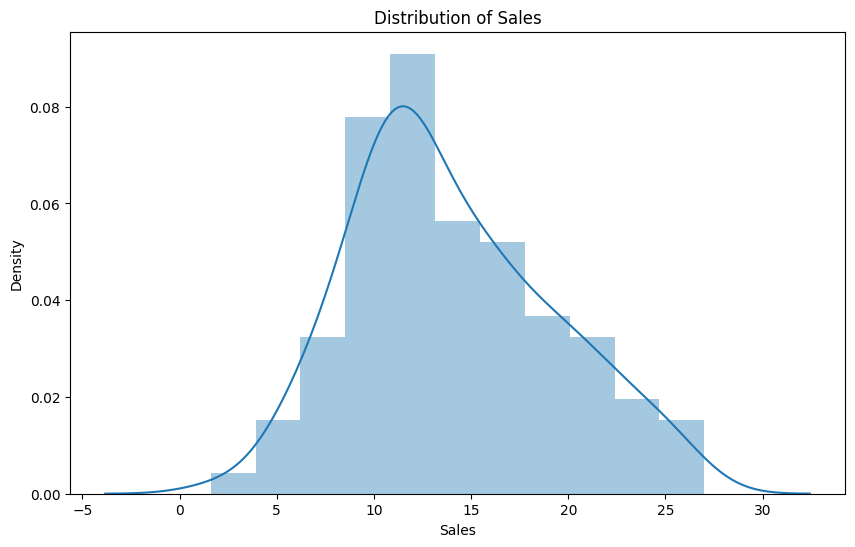

In [13]:
#Distribution of Sales helps understand whether Sales data is normally distributed.

plt.figure(figsize = (10, 6))
sns.distplot(df['Sales'])
plt.title('Distribution of Sales')
plt.show()

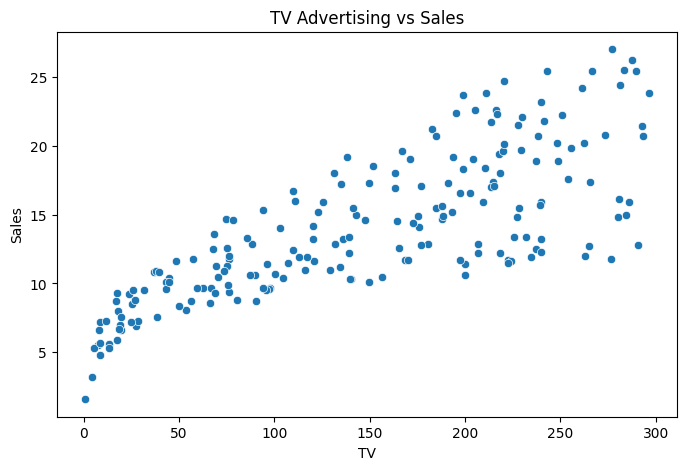

In [14]:
#TV vs. Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x="TV", y="Sales", data=df)

plt.title("TV Advertising vs Sales")
plt.show()

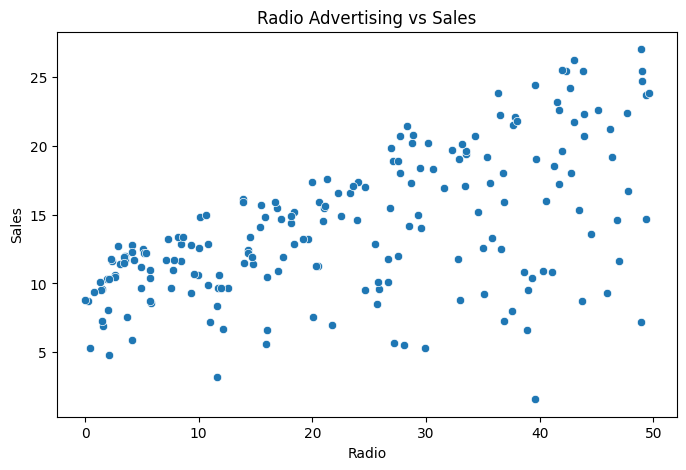

In [15]:
#Radio vs. Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x="Radio", y="Sales", data=df)

plt.title("Radio Advertising vs Sales")
plt.show()

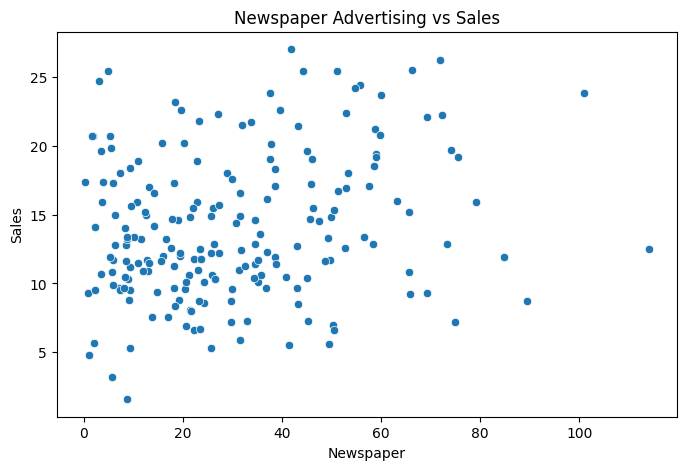

In [16]:
#Newspaper vs. Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x="Newspaper", y="Sales", data=df)

plt.title("Newspaper Advertising vs Sales")
plt.show()

#*Insights*

## Key Findings

1. TV advertising has the strongest positive relationship with Sales.
2. Radio also contributes significantly.
3. Newspaper has the weakest impact.
4. No major outliers detected.
5. Data appears clean and suitable for Linear Regression.

**7. Feature Selection**

X = Input Features

- TV
- Radio
- Newspaper

y = Target Variable

- Sales

In [17]:
X = df.drop("Sales", axis = 1)

Y = df['Sales']

**8. Train Test Split**

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size = 0.2,
    random_state = 42
)

Training Data = 80%

Testing Data = 20%

**9. Model Building**

In [19]:
model =  LinearRegression()

model.fit(X_train, Y_train)

LinearRegression()

Linear Regression learns relationships between advertising spend and sales.

**10. Prediction**

In [24]:
y_pred = model.predict(X_test)

y_pred[:5]  #gives first 5 predicted values

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326])

**11. Model Evaluation**

In [26]:
#Mean Absolute Error  - average prediction error
mae = mean_absolute_error(Y_test, y_pred)
print("Mean Absolute Error:", round(mae, 2))

Mean Absolute Error: 1.46


Here, MAE is lower so it is better.

In [27]:
#Roor Mean Square Error - Measures prediction error in actual sales units.
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
print("Root Mean Squared Error:", round(rmse, 2))

Root Mean Squared Error: 1.78


Here, RMSE is lower so it is better.

In [30]:
#R-square Score - Explains how much variation in Sales is captured by the model.
r2 = r2_score(Y_test, y_pred)
print("R-Squared Score:", round(r2, 2), "or ", round(r2*100, 2), "%")

R-Squared Score: 0.9 or  89.94 %


The model explains approximately 0.9 or 89.94% of the variation in Sales.

**12. Actual vs Predicted Visualization**

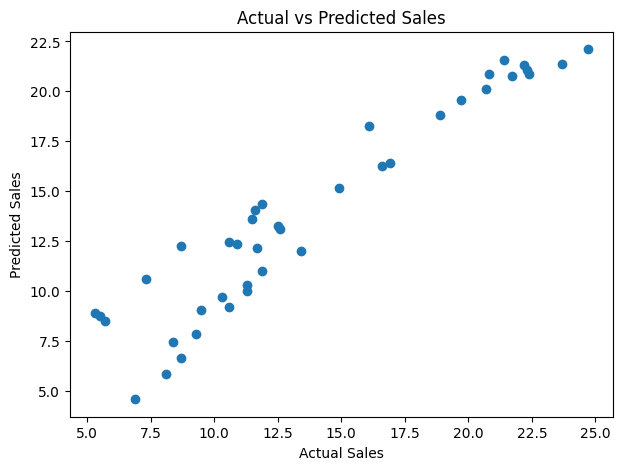

In [32]:
plt.figure(figsize=(7,5))

plt.scatter(Y_test, y_pred)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

If points lie near a straight line, predictions are accurate.

**13. Feature Importance**

It shows which advertising platform contributes most to sales.

In [33]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
1,Radio,0.189195
0,TV,0.044730
2,Newspaper,0.002761


# Conclusion

A Linear Regression model was developed to predict sales based on advertising expenditure.

Key findings:

- TV advertising has the strongest impact on sales.
- Radio advertising also contributes positively.
- Newspaper advertising has relatively low influence.
- The model achieved a high R² score, indicating strong predictive performance.

The model can help businesses allocate advertising budgets more effectively.

In [34]:
#saving the trained model
import pickle

with open("sales_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model Saved Successfully!")

Model Saved Successfully!
